# Task 6: House Price Prediction

## Objective
We will predict house prices using machine learning without any external dataset.

We will create a synthetic dataset with:
- Square footage
- Number of bedrooms
- Location

Then we will train a regression model to predict house prices.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

## Step 1: Create Synthetic Dataset

Since we don't have a CSV file, we will generate our own dataset.

In [4]:
np.random.seed(42)

df = pd.DataFrame({
    "sqft": np.random.randint(500, 3500, 200),
    "bedrooms": np.random.randint(1, 6, 200),
    "location": np.random.choice(["A", "B", "C"], 200),
})

# Create a realistic price formula
df["price"] = (
    df["sqft"] * 180 +
    df["bedrooms"] * 7000 +
    np.random.randint(10000, 60000, 200)
)

df.head()

,sqft,bedrooms,location,price
0,1360,4,B,300724
1,1794,4,C,383476
2,1630,2,A,344362
3,1595,3,C,346395
4,2138,1,C,415647


## Step 2: Data Preprocessing
We convert categorical data (location) into numeric form.

In [5]:
le = LabelEncoder()
df["location"] = le.fit_transform(df["location"])

df.head()

,sqft,bedrooms,location,price
0,1360,4,1,300724
1,1794,4,2,383476
2,1630,2,0,344362
3,1595,3,2,346395
4,2138,1,2,415647


## Step 3: Define Features and Target

In [6]:
X = df[["sqft", "bedrooms", "location"]]
y = df["price"]

## Step 4: Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 5: Train Linear Regression Model

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Step 6: Predictions

In [9]:
y_pred = model.predict(X_test)

## Step 7: Evaluation Metrics
We use:
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)

In [10]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 12596.900959780238
Root Mean Squared Error (RMSE): 14763.077982624618


## Step 8: Visualization (Actual vs Predicted)

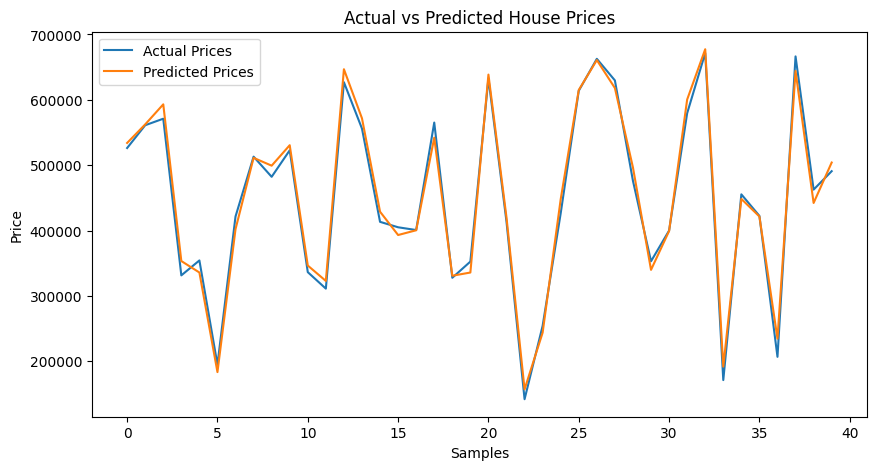

In [11]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values, label="Actual Prices")
plt.plot(y_pred, label="Predicted Prices")

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Samples")
plt.ylabel("Price")
plt.legend()

plt.show()